In [ ]:
# --- Installation ---
print("Installing required libraries...")
!pip install -q tensorflow tensorflow_model_optimization scikit-learn matplotlib seaborn matplotlib mediapipe opencv-python tabulate
print("Installation complete.")

Installing required libraries...
Installation complete.


In [ ]:
# --- Standard Libraries ---
import os
import time
import timeit

# --- Scientific and Data Handling Libraries ---
import numpy as np
import pandas as pd

# --- Visualization Libraries ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine Learning Libraries ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# --- Deep Learning Libraries ---
import tensorflow as tf
import tensorflow_model_optimization as tfmot
import keras
from tensorflow.keras import layers, models, callbacks, regularizers, utils

# --- Computer Vision Library ---
import cv2

# --- Google Colab ---
from google.colab import drive

# --- Progress Bar ---
from tqdm.notebook import tqdm



In [ ]:
# --- Reproducibility ---
# Set a seed for random operations to ensure that results are consistent across runs.
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("\nLibraries imported and seed set for reproducibility.")


Libraries imported and seed set for reproducibility.


In [ ]:
# --- Mount Google Drive ---
print("Mounting Google Drive...")
drive.mount('/content/drive')


Mounting Google Drive...
Mounted at /content/drive


In [ ]:
# --- Load Data (mediapipe features) ---
DATA_PATH = '/content/drive/MyDrive/major_project/features/'
X_path = os.path.join(DATA_PATH, 'X_original_increased_sampled_mixture_augmentation.npy')
y_path = os.path.join(DATA_PATH, 'y_original_increased_sampled_mixture_augmentation.npy')

print(f"\nLoading data from {DATA_PATH}...")
X = np.load(X_path)
y = np.load(y_path)

print(f"\nData loaded. X shape: {X.shape}, y shape: {y.shape}")


Loading data from /content/drive/MyDrive/major_project/features/...

Data loaded. X shape: (3960, 75, 177), y shape: (3960, 33)


In [ ]:
# --- Split Data (70% Train, 20% Test, 10% Validation) ---
print("Splitting data into training, validation, and test sets...")

# First split: Separate 20% for the test set.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Second split: Split the remaining data (80%) into training (70%) and validation (10%).
# The validation size relative to the temp set is 10 / (70 + 10) = 0.125
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=SEED, stratify=y_temp
)

print("\nData splitting complete.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}, y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")

# For example, if:
# Class A has 100 samples
# Class B has 70 samples
# Class C has 90 samples
# Then the 70-10-20 split with stratify will give:
# Train: 70% of A, B, C
# Val: 10% of A, B, C
# Test: 20% of A, B, C

Splitting data into training, validation, and test sets...

Data splitting complete.
X_train shape: (2772, 75, 177), y_train shape: (2772, 33)
X_val shape:   (396, 75, 177), y_val shape:   (396, 33)
X_test shape:  (792, 75, 177), y_test shape:  (792, 33)


In [ ]:
# ---- define model -----

# 🔧 Positional Encoding Layer
@keras.utils.register_keras_serializable(package="custom")
class PositionalEncodingLayer(layers.Layer):
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.seq_len  = seq_len
        self.d_model  = d_model
        self.pos_encoding = self._positional_encoding(seq_len, d_model)

    # -----  Keras serialization  -----
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"seq_len": self.seq_len, "d_model": self.d_model})
        return cfg

    @classmethod
    def from_config(cls, config):
        return cls(**config)

    # -----  Core logic  -----
    def _positional_encoding(self, seq_len, d_model):
        pos   = tf.range(seq_len, dtype=tf.float32)[:, tf.newaxis]
        i     = tf.range(d_model, dtype=tf.float32)[tf.newaxis, :]
        angle = 1 / tf.pow(10000.0, (2 * (i // 2)) / tf.cast(d_model, tf.float32))
        angle = pos * angle
        sines = tf.sin(angle[:, 0::2])
        coses = tf.cos(angle[:, 1::2])
        encoding = tf.concat([sines, coses], axis=-1)
        return encoding[tf.newaxis, ...]

    def call(self, inputs):
        return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]

# 🧠 Transformer Encoder Block
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.3):
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size,
                                  dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    x = layers.Add()([inputs, x])              # residual

    y = layers.LayerNormalization(epsilon=1e-6)(x)

    # ffn
    y = layers.Dense(ff_dim, activation="gelu",
                     kernel_regularizer=regularizers.l2(1e-4))(y)
    y = layers.Dropout(dropout)(y)
    y = layers.Dense(inputs.shape[-1])(y)
    y = layers.Dropout(dropout)(y)
    return layers.Add()([x, y])                # residual

# 🏗️  Model Builder
def build_transformer_model(input_shape, num_classes):
    inp = layers.Input(shape=input_shape)
    x   = PositionalEncodingLayer(input_shape[0], input_shape[1])(inp)

    for _ in range(4):
        x = transformer_encoder(x, head_size=64, num_heads=4,
                                ff_dim=128, dropout=0.3)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inp, out)

print("✅ PositionalEncodingLayer is now fully registered and serializable.")

✅ PositionalEncodingLayer is now fully registered and serializable.


In [ ]:
# --- Get Model Parameters ---
input_shape = X_train.shape[1:]
num_classes = y_train.shape[1]

# --- Build and Compile ---
print(f"Building model with input shape: {input_shape} and {num_classes} classes.")
model = build_transformer_model(input_shape, num_classes)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Building model with input shape: (75, 177) and 33 classes.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 75, 177)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encodin… │ (None, 75, 177)   │          0 │ input_layer_1[0]… │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 75, 177)   │        354 │ positional_encod… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 75, 177)   │    182,193 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 75, 177)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 75, 177)   │          0 │ positional_encod… │
│                     │                   │            │ dropout_22[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 75, 177)   │        354 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 75, 128)   │     22,784 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_23          │ (None, 75, 128)   │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 75, 177)   │     22,833 │ dropout_23[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 75, 177)   │          0 │ dense_11[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 75, 177)   │          0 │ add_8[0][0],      │
│                     │                   │            │ dropout_24[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 75, 177)   │        354 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 75, 177)   │    182,193 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 75, 177)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 75, 177)   │          0 │ add_9[0][0],      │
│                     │                   │            │ dropout_26[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 75, 177)   │        354 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 941,625 (3.59 MB)

 Trainable params: 941,369 (3.59 MB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
# --- Define Callbacks ---
# Define the path for saving the best model using the .keras format
checkpoint_path = "/content/drive/MyDrive/major_project/models/checkpoint_models/transformer_mixed_best_model.keras"

# Stop training when validation loss doesn't improve for 10 epochs
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
)
# Save the best model based on validation accuracy
model_checkpoint = callbacks.ModelCheckpoint(
    filepath=checkpoint_path, monitor='val_accuracy', save_best_only=True, verbose=1
)
# Reduce learning rate when validation loss plateaus
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1
)

In [ ]:
# --- Train the Model ---
print("\nStarting model training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,  # A high number; EarlyStopping will find the optimal point
    batch_size=32,
    callbacks=[early_stopping, model_checkpoint, reduce_lr]
)
print("\nModel training complete.")

# --- Extract Best Epoch Based on Validation Accuracy ---
val_acc = history.history['val_accuracy']
train_acc = history.history['accuracy']
val_loss = history.history['val_loss']
train_loss = history.history['loss']

best_epoch = np.argmax(val_acc)
print(f"\nBest Epoch: {best_epoch + 1}")
print(f"Train Accuracy   : {train_acc[best_epoch]*100:.2f}%")
print(f"Validation Accuracy: {val_acc[best_epoch]*100:.2f}%")
print(f"Train Loss       : {train_loss[best_epoch]:.4f}")
print(f"Validation Loss  : {val_loss[best_epoch]:.4f}")



Starting model training...
Epoch 1/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.0581 - loss: 3.9920
Epoch 1: val_accuracy improved from -inf to 0.07576, saving model to /content/drive/MyDrive/major_project/models/checkpoint_models/transformer_mixed_best_model.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 46s 220ms/step - accuracy: 0.0583 - loss: 3.9893 - val_accuracy: 0.0758 - val_loss: 3.8389 - learning_rate: 1.0000e-04
Epoch 2/200
86/87 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1186 - loss: 3.3470
Epoch 2: val_accuracy improved from 0.07576 to 0.12626, saving model to /content/drive/MyDrive/major_project/models/checkpoint_models/transformer_mixed_best_model.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.1187 - loss: 3.3457 - val_accuracy: 0.1263 - val_loss: 3.1474 - learning_rate: 1.0000e-04
Epoch 3/200
86/87 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1642 - loss: 3.0268
Epoch 3: val_accuracy improved from 0.12626 to 0.17172, saving model to /content/drive/M

In [ ]:
# --- Load Best Model ---
print("\nLoading the best model for final evaluation...")
best_model = models.load_model(
    checkpoint_path,
    custom_objects={"PositionalEncodingLayer": PositionalEncodingLayer}
)

# --- Evaluate on Test Set ---
print("Evaluating model on the test set...")
loss, accuracy = best_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")



Loading the best model for final evaluation...
Evaluating model on the test set...

Test Loss: 0.4240
Test Accuracy: 91.54%


In [ ]:
# --- Path to save metrics ---
import os
from datetime import datetime

# Set output directory in Google Drive
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
output_dir = f"/content/drive/MyDrive/major_project/metrics/transformer_mixed_training_metrics/Run_{timestamp}"
# /content/drive/MyDrive/major_project/models/checkpoint_models/original_increased_sampled_mixture_augmentation_best_model.keras
os.makedirs(output_dir, exist_ok=True)


Displaying model training history...


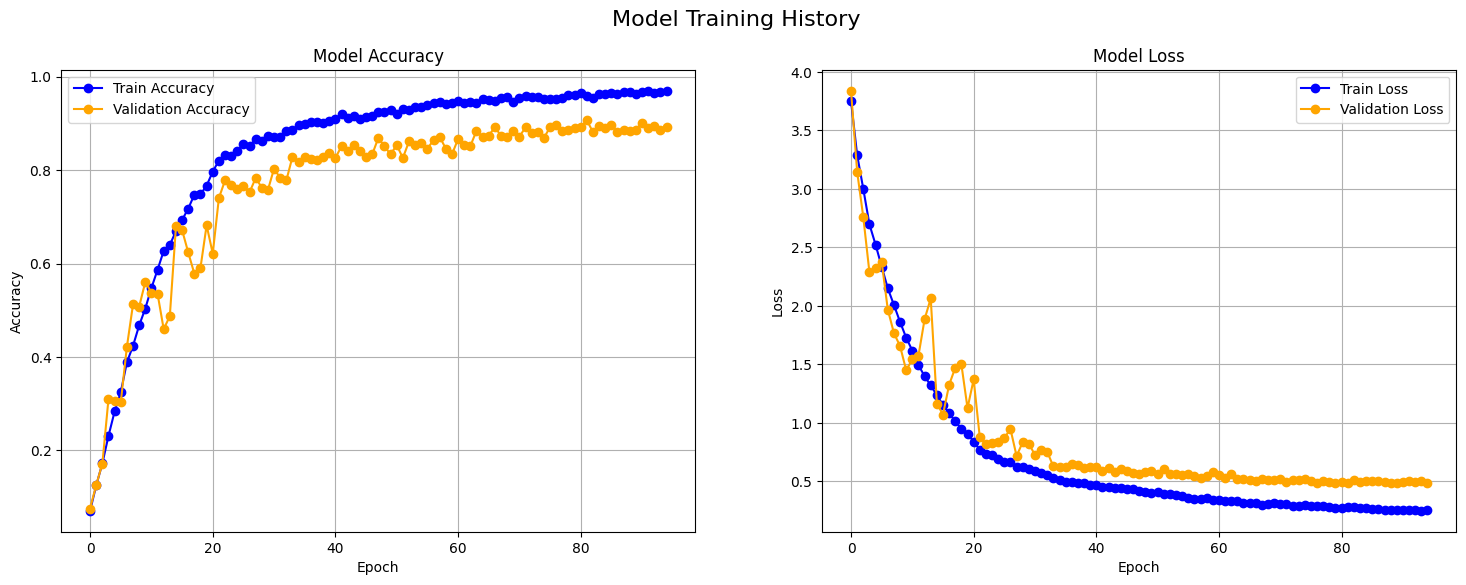


Generating predictions and performance metrics...
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step

           Classification Report
                 precision    recall  f1-score   support

      Afternoon       0.88      0.96      0.92        24
          Apple       0.85      0.92      0.88        24
          April       0.79      0.79      0.79        24
         August       0.96      0.96      0.96        24
         Banana       0.96      0.96      0.96        24
            Day       1.00      0.96      0.98        24
       December       1.00      0.92      0.96        24
        Evening       0.96      0.96      0.96        24
       February       1.00      0.79      0.88        24
         Friday       1.00      0.96      0.98        24
         Grapes       0.83      0.79      0.81        24
        January       0.88      0.96      0.92        24
           July       1.00      1.00      1.00        24
           June       0.94      0.71      0.81        24
          March    

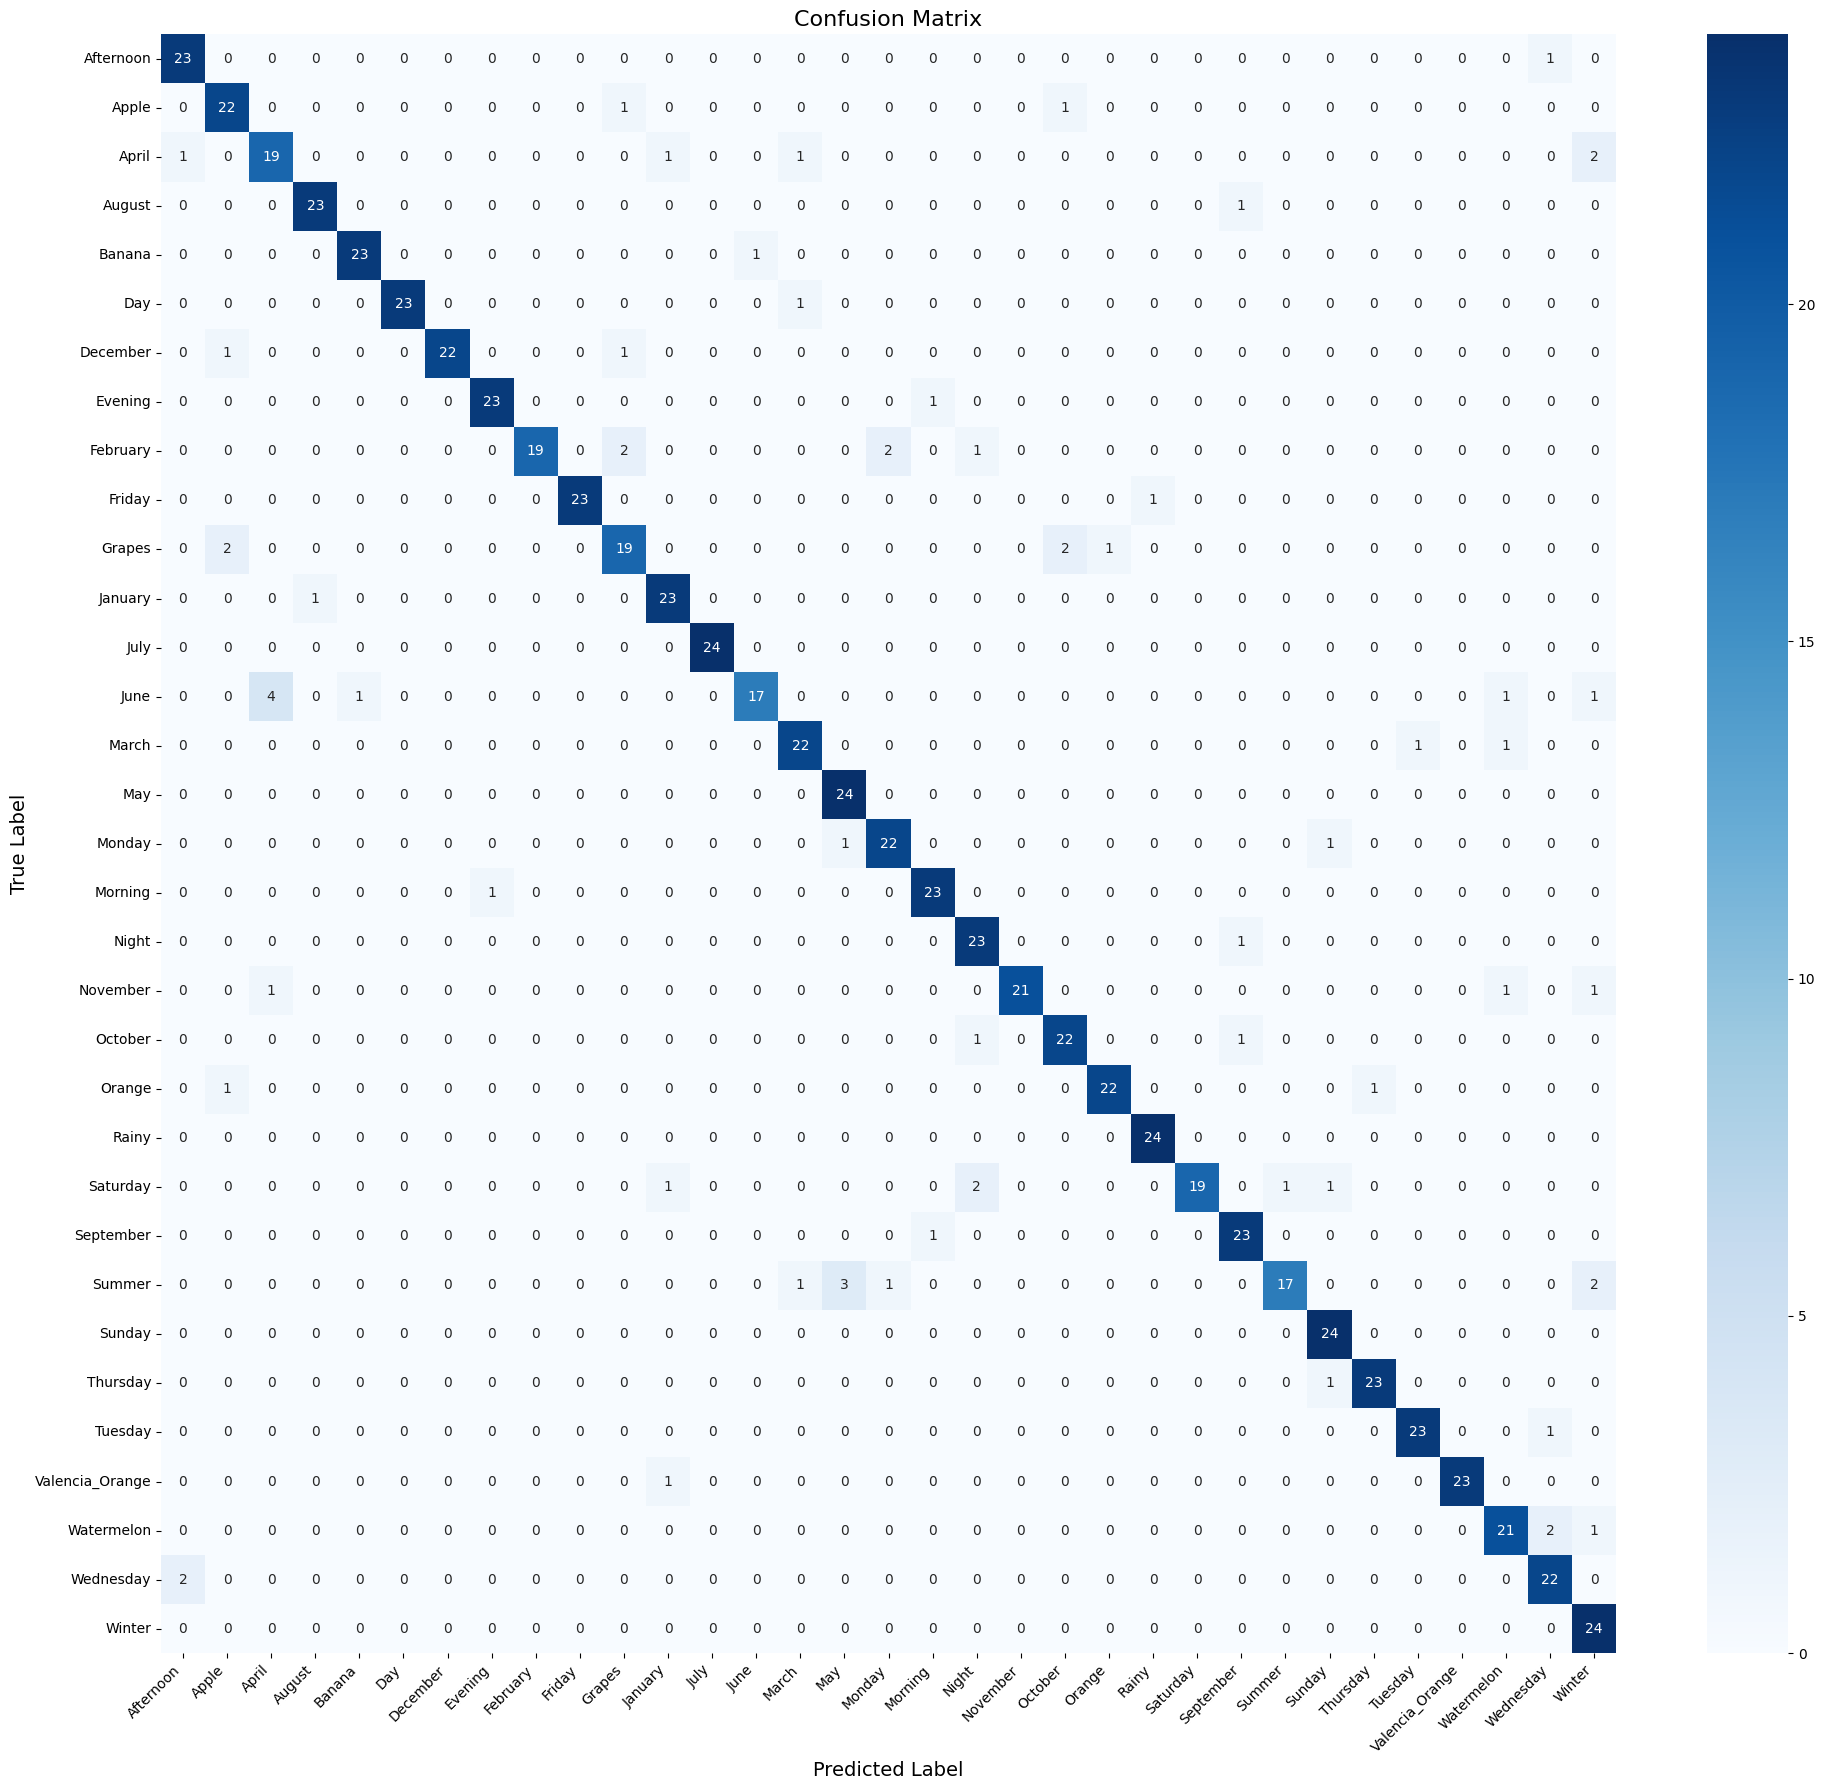


Displaying F1-Scores for each class...


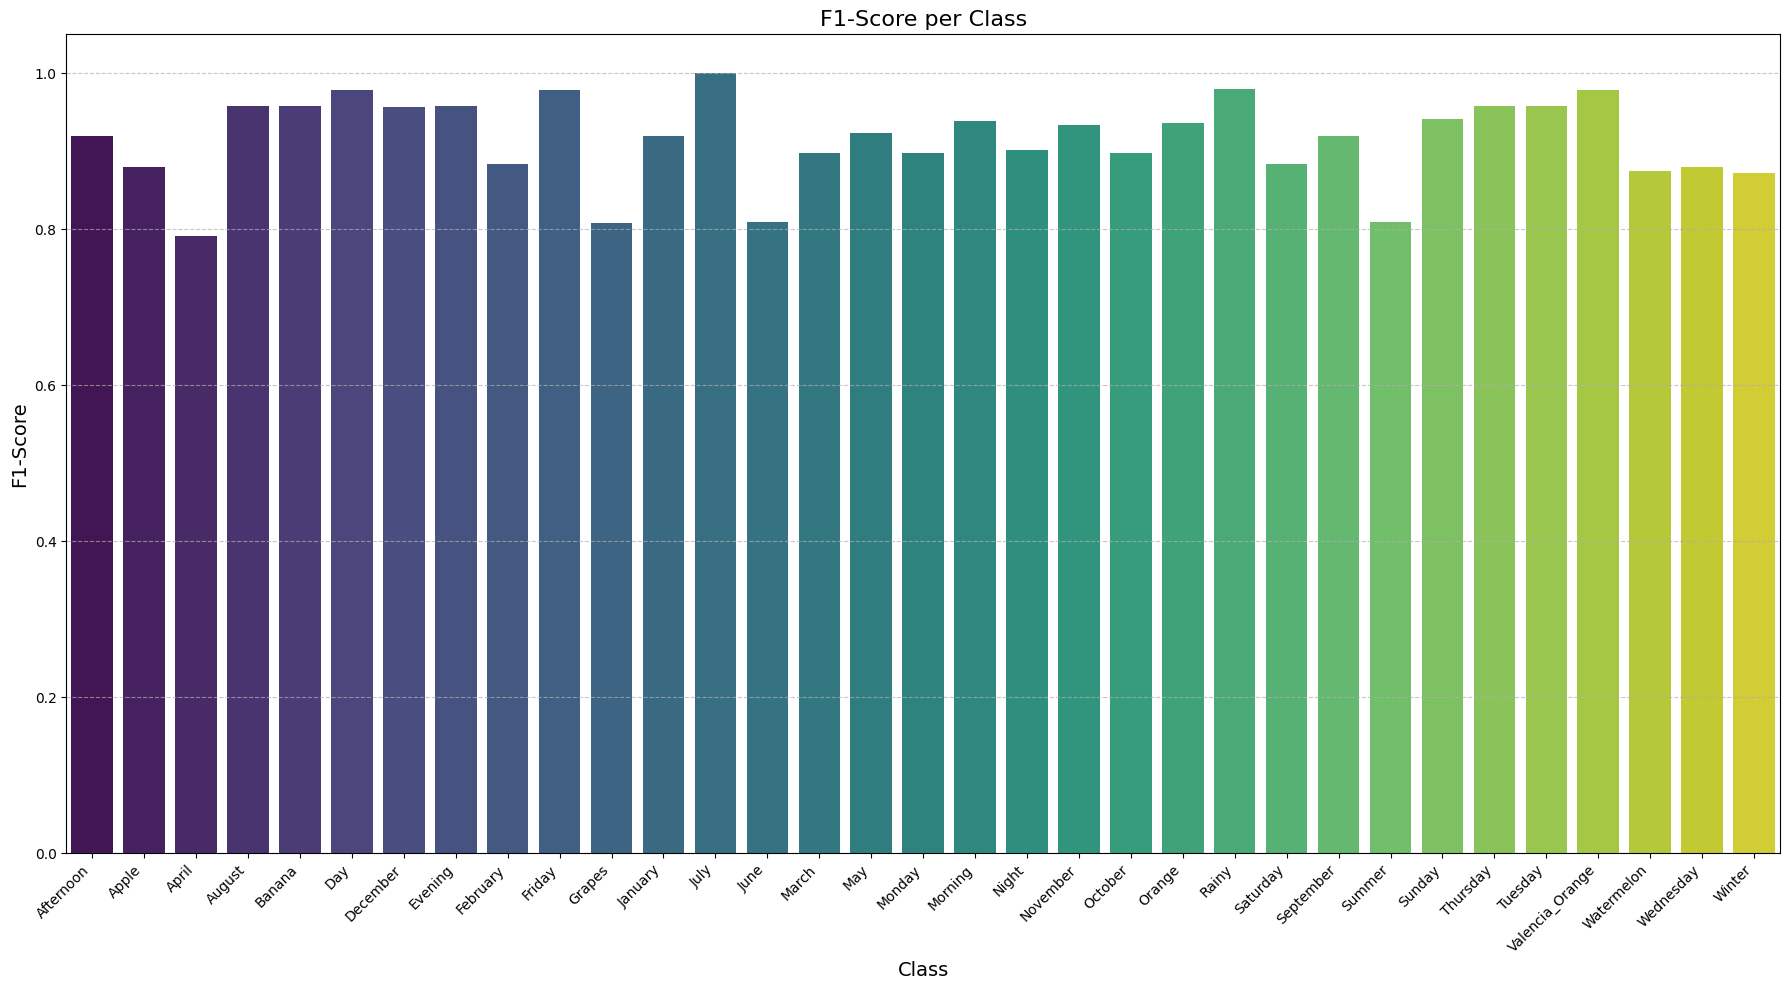


         Overall Model Performance Summary
✅ Overall Accuracy:           0.9154
🎯 Overall Precision (Weighted): 0.9202
🎯 Overall Recall (Weighted):    0.9154
🎯 Overall F1-Score (Weighted):  0.9147


In [ ]:
# --- Visualization ---

# 'history', 'best_model', 'X_test', and 'y_test' are already defined.

# ==============================================================================
# IMPORTANT: class names
# ==============================================================================
class_names = [
    'Afternoon', 'Apple', 'April', 'August', 'Banana', 'Day', 'December',
    'Evening', 'February', 'Friday', 'Grapes', 'January', 'July', 'June',
    'March', 'May', 'Monday', 'Morning', 'Night', 'November', 'October',
    'Orange', 'Rainy', 'Saturday', 'September', 'Summer', 'Sunday',
    'Thursday', 'Tuesday', 'Valencia_Orange', 'Watermelon', 'Wednesday', 'Winter'
]


# --- 1. Plot Training History (Accuracy & Loss Curves) ---
print("Displaying model training history...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Model Training History', fontsize=16)

# Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='blue', marker='o')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'], label='Train Loss', color='blue', marker='o')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange', marker='o')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)
plt.savefig(f"{output_dir}/training_history.png", dpi=1000)
plt.show()


# --- 2. Generate Predictions and Detailed Report ---
print("\nGenerating predictions and performance metrics...")
y_pred_probs = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("\n" + "="*60)
print("           Classification Report")
print("="*60)
report_dict = classification_report(y_true_classes, y_pred_classes,
                                    target_names=class_names, output_dict=True)
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


# --- 3. Visualize Per-Class Performance ---

# Confusion Matrix
print("\nDisplaying Confusion Matrix...")
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{output_dir}/confusion_matrix.png", dpi=1000)
plt.show()

# F1-Score Bar Chart
print("\nDisplaying F1-Scores for each class...")
report_df = pd.DataFrame(report_dict).transpose()
report_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'])

plt.figure(figsize=(18, 10))
sns.barplot(data=report_df, x=report_df.index, y='f1-score',
            hue=report_df.index, palette='viridis', legend=False)
plt.title('F1-Score per Class', fontsize=16)
plt.xlabel('Class', fontsize=14)
plt.ylabel('F1-Score', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f"{output_dir}/f1_scores.png", dpi=1000)
plt.show()


# --- 4. Display Overall Model Metrics Separately (NEW) ---
print("\n" + "="*60)
print("         Overall Model Performance Summary")
print("="*60)

# Extracting the overall metrics from the report dictionary
overall_accuracy = report_dict['accuracy']
weighted_avg_metrics = report_dict['weighted avg']
overall_precision = weighted_avg_metrics['precision']
overall_recall = weighted_avg_metrics['recall']
overall_f1 = weighted_avg_metrics['f1-score']

print(f"✅ Overall Accuracy:           {overall_accuracy:.4f}")
print(f"🎯 Overall Precision (Weighted): {overall_precision:.4f}")
print(f"🎯 Overall Recall (Weighted):    {overall_recall:.4f}")
print(f"🎯 Overall F1-Score (Weighted):  {overall_f1:.4f}")
print("="*60)

In [ ]:
# --- Save Classification Report to Files ---

# Save the classification report DataFrame to a CSV file for easy spreadsheet access.
report_df.to_csv(f"{output_dir}/classification_report.csv")

# Save the classification report DataFrame to a JSON file for structured data interchange.
report_df.to_json(f"{output_dir}/classification_report.json", indent=4)

In [ ]:
# Create a dictionary to store the overall performance metrics.
# This makes it easy to save these metrics in a structured format like JSON.
overall_metrics = {
    "accuracy": overall_accuracy,
    "precision": overall_precision,
    "recall": overall_recall,
    "f1_score": overall_f1
}

# Save the overall metrics to a JSON file.
# The 'w' mode opens the file for writing, and 'indent=4' makes the JSON file human-readable.
with open(f"{output_dir}/overall_metrics.json", "w") as f:
    import json
    json.dump(overall_metrics, f, indent=4)

# Save the true and predicted labels to NumPy files.
# This allows for more detailed analysis later without needing to re-run the model.
np.save(f"{output_dir}/y_true.npy", y_true_classes)
np.save(f"{output_dir}/y_pred.npy", y_pred_classes)

In [ ]:
# --- Save Final Model for conversion and  Deployment ---

# --- Define Save Path ---
# This saves the final, trained model in the native Keras v3 format.
# This single file contains the architecture, weights, and optimizer state.
final_model_path = "/content/drive/MyDrive/major_project/models/keras_models/transformer_mixed_model.keras"

# --- Save Model ---
print(f"\nSaving the final trained model to: {final_model_path}")
model.save(final_model_path)
print("Model saved successfully.")
print("\nThis file can now be loaded elsewhere for inference or TFLite conversion.")


Saving the final trained model to: /content/drive/MyDrive/major_project/models/keras_models/transformer_mixed_model.keras
Model saved successfully.

This file can now be loaded elsewhere for inference or TFLite conversion.


In [ ]:
# ------------------------------------------- END OF TRAINING ------------------------

In [ ]:
# ---  Core Paths ---
DRIVE_BASE_PATH = '/content/drive/MyDrive/major_project'

# Input paths
FEATURES_PATH = os.path.join(DRIVE_BASE_PATH, 'features')
KERAS_MODEL_PATH = os.path.join(DRIVE_BASE_PATH, 'models/keras_models/transformer_mixed_model.keras')

# Output paths
TFLITE_MODELS_DIR = os.path.join(DRIVE_BASE_PATH, 'models/tflite_models')
os.makedirs(TFLITE_MODELS_DIR, exist_ok=True) # Ensure the directory exists

MODEL_PATH_TFLITE_STANDARD = os.path.join(TFLITE_MODELS_DIR, 'transformer_mixed_model_standard.tflite')
MODEL_PATH_TFLITE_PTQ = os.path.join(TFLITE_MODELS_DIR, 'transformer_mixed_model_ptq_dynamic.tflite')
MODEL_PATH_TFLITE_PTQ_FULL = os.path.join(TFLITE_MODELS_DIR, 'transformer_mixed_model_ptq_full.tflite')
MODEL_PATH_TFLITE_PTQ_FULL_FLOAT = os.path.join(TFLITE_MODELS_DIR, 'transformer_mixed_model_ptq_full_float.tflite')
MODEL_PATH_TFLITE_PTQ_FLOAT16 = os.path.join(TFLITE_MODELS_DIR, 'transformer_mixed_model_ptq_float16.tflite')

print("\nAll paths configured.")


All paths configured.


In [ ]:
# ==============================================================================
# Load Baseline Keras Model
# ==============================================================================
print(f"Loading baseline Keras model from: {KERAS_MODEL_PATH}")

model_keras = tf.keras.models.load_model(
    KERAS_MODEL_PATH,
    custom_objects={'PositionalEncodingLayer': PositionalEncodingLayer}
)

print("✅ Baseline Keras model loaded successfully.")
model_keras.summary()

Loading baseline Keras model from: /content/drive/MyDrive/major_project/models/keras_models/transformer_mixed_model.keras
✅ Baseline Keras model loaded successfully.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 75, 177)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encodin… │ (None, 75, 177)   │          0 │ input_layer_1[0]… │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 75, 177)   │        354 │ positional_encod… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 75, 177)   │    182,193 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 75, 177)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 75, 177)   │          0 │ positional_encod… │
│                     │                   │            │ dropout_22[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 75, 177)   │        354 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 75, 128)   │     22,784 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_23          │ (None, 75, 128)   │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 75, 177)   │     22,833 │ dropout_23[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 75, 177)   │          0 │ dense_11[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 75, 177)   │          0 │ add_8[0][0],      │
│                     │                   │            │ dropout_24[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 75, 177)   │        354 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 75, 177)   │    182,193 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 75, 177)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 75, 177)   │          0 │ add_9[0][0],      │
│                     │                   │            │ dropout_26[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 75, 177)   │        354 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,824,365 (10.77 MB)

 Trainable params: 941,369 (3.59 MB)

 Non-trainable params: 256 (1.00 KB)

 Optimizer params: 1,882,740 (7.18 MB)

In [ ]:
# ==============================================================================
# Standard TFLite Conversion
# ==============================================================================
print(f"Converting Keras model to standard TFLite format...")

converter = tf.lite.TFLiteConverter.from_keras_model(model_keras)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]
converter.experimental_enable_resource_variables = True
tflite_model_standard = converter.convert()

with open(MODEL_PATH_TFLITE_STANDARD, 'wb') as f:
    f.write(tflite_model_standard)

print(f"✅ Standard TFLite model saved to: {MODEL_PATH_TFLITE_STANDARD}")

Converting Keras model to standard TFLite format...
Saved artifact at '/tmp/tmppfdrbwro'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 75, 177), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 33), dtype=tf.float32, name=None)
Captures:
  138809699648528: TensorSpec(shape=(1, 75, 177), dtype=tf.float32, name=None)
  138809822311824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809822313744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699647760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699649488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699647952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699650256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699649680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699651024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699648144: TensorSp

In [ ]:
# ==============================================================================
# Post-Training Quantization (Weight Analysis)
# ==============================================================================

import numpy as np

print(f"🔧 Applying Post-Training Quantization...")

# === Print original model precision ===
float_weights = 0
total_weights = 0
for layer in model_keras.layers:
    for weight in layer.get_weights():
        total_weights += weight.size
        if weight.dtype == np.float32:
            float_weights += weight.size

print(f"🔍 Original model precision:")
print(f"   - Total weights: {total_weights}")
print(f"   - Float32 weights: {float_weights} ({(float_weights/total_weights)*100:.2f}%)")

🔧 Applying Post-Training Quantization...
🔍 Original model precision:
   - Total weights: 941625
   - Float32 weights: 941625 (100.00%)


In [ ]:
# ------------------------------------------------------------------------------
# Dynamic Range Quantization
# ------------------------------------------------------------------------------
print(f"\n📦 Converting using Dynamic Range Quantization...")

converter_dynamic = tf.lite.TFLiteConverter.from_keras_model(model_keras)
converter_dynamic.optimizations = [tf.lite.Optimize.DEFAULT]

converter_dynamic.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS
]

tflite_model_ptq = converter_dynamic.convert()
with open(MODEL_PATH_TFLITE_PTQ, 'wb') as f:
    f.write(tflite_model_ptq)

print(f"✅ Dynamic Range Quantized model saved at: {MODEL_PATH_TFLITE_PTQ}")
print(f"   → Weights: int8, Activations: float32, Ops: Builtins")



📦 Converting using Dynamic Range Quantization...
Saved artifact at '/tmp/tmpk37dsyjh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 75, 177), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 33), dtype=tf.float32, name=None)
Captures:
  138809699648528: TensorSpec(shape=(1, 75, 177), dtype=tf.float32, name=None)
  138809822311824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809822313744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699647760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699649488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699647952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699650256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699649680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699651024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699648144: TensorSpec

In [ ]:
# ------------------------------------------------------------------------------
#  Full Integer Quantization, Inputs/Outputs: int8
# ------------------------------------------------------------------------------
print(f"\n📦 Converting using Full Integer Quantization...")

# Define a representative dataset for full integer quantization.
# A small subset of the training data is used for calibration.
# The data needs to be in the format expected by the model's input layer.
def representative_data_gen():
    # Use a small subset of the training data for calibration
    num_calibration_steps = 500  # You can adjust this number
    for i in range(num_calibration_steps):
        # Provide the data with the expected input shape and data type
        yield [X_train[i:i+1].astype(np.float32)]



converter_full = tf.lite.TFLiteConverter.from_keras_model(model_keras)
converter_full.optimizations = [tf.lite.Optimize.DEFAULT]
converter_full.representative_dataset = representative_data_gen

# # --- FORCE INT8 INPUT AND OUTPUT ---
converter_full.inference_input_type = tf.int8
converter_full.inference_output_type = tf.int8

converter_full.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS
]

tflite_model_full = converter_full.convert()
with open(MODEL_PATH_TFLITE_PTQ_FULL, 'wb') as f:
    f.write(tflite_model_full)

print(f"✅ Full Integer Quantized model saved at: {MODEL_PATH_TFLITE_PTQ_FULL}")
print(f"   → Weights: int8, Activations: int8, Ops: Builtins")


📦 Converting using Full Integer Quantization...
Saved artifact at '/tmp/tmpali0a1ak'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 75, 177), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 33), dtype=tf.float32, name=None)
Captures:
  138809699648528: TensorSpec(shape=(1, 75, 177), dtype=tf.float32, name=None)
  138809822311824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809822313744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699647760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699649488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699647952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699650256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699649680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699651024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699648144: TensorSpec(

/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✅ Full Integer Quantized model saved at: /content/drive/MyDrive/major_project/models/tflite_models/transformer_mixed_model_ptq_full.tflite
   → Weights: int8, Activations: int8, Ops: Builtins


In [ ]:
# ------------------------------------------------------------------------------
#  Full Integer Quantization with Float32 IO/OP
# ------------------------------------------------------------------------------
print(f"\n📦 Converting using Full Integer Quantization...")

# Define a representative dataset for full integer quantization.
# A small subset of the training data is used for calibration.
# The data needs to be in the format expected by the model's input layer.
def representative_data_gen():
    # Use a small subset of the training data for calibration
    num_calibration_steps = 500  # You can adjust this number
    for i in range(num_calibration_steps):
        # Provide the data with the expected input shape and data type
        yield [X_train[i:i+1].astype(np.float32)]



converter_full_float = tf.lite.TFLiteConverter.from_keras_model(model_keras)
converter_full_float.optimizations = [tf.lite.Optimize.DEFAULT]
converter_full_float.representative_dataset = representative_data_gen


converter_full_float.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS
]

tflite_model_full_float = converter_full_float.convert()
with open(MODEL_PATH_TFLITE_PTQ_FULL_FLOAT, 'wb') as f:
    f.write(tflite_model_full_float)

print(f"✅ Full Integer Quantized model saved at: {MODEL_PATH_TFLITE_PTQ_FULL_FLOAT}")
print(f"   → Weights: int8, Activations: int8, Inputs/Outputs: float32, Ops: Builtins")


📦 Converting using Full Integer Quantization...
Saved artifact at '/tmp/tmpz8ggazfz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 75, 177), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 33), dtype=tf.float32, name=None)
Captures:
  138809699648528: TensorSpec(shape=(1, 75, 177), dtype=tf.float32, name=None)
  138809822311824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809822313744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699647760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699649488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699647952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699650256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699649680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699651024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699648144: TensorSpec(

/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✅ Full Integer Quantized model saved at: /content/drive/MyDrive/major_project/models/tflite_models/transformer_mixed_model_ptq_full_float.tflite
   → Weights: int8, Activations: int8, Inputs/Outputs: float32, Ops: Builtins


In [ ]:
# ------------------------------------------------------------------------------
# Float16 quantization
# ------------------------------------------------------------------------------
print(f"\n📦 Converting using Dynamic Range Quantization...")

converter_float16 = tf.lite.TFLiteConverter.from_keras_model(model_keras)
converter_float16.optimizations = [tf.lite.Optimize.DEFAULT]

converter_float16.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS
]
converter_float16.target_spec.supported_types = [tf.float16]
tflite_model_ptq = converter_float16.convert()
with open(MODEL_PATH_TFLITE_PTQ_FLOAT16, 'wb') as f:
    f.write(tflite_model_ptq)

print(f"✅ Dynamic Range Quantized model saved at: {MODEL_PATH_TFLITE_PTQ_FLOAT16}")
print(f"   → Weights: float16, Activations: float32, Ops: Builtins")



📦 Converting using Dynamic Range Quantization...
Saved artifact at '/tmp/tmp_l5i9ahw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 75, 177), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 33), dtype=tf.float32, name=None)
Captures:
  138809699648528: TensorSpec(shape=(1, 75, 177), dtype=tf.float32, name=None)
  138809822311824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809822313744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699647760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699649488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699647952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699650256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699649680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699651024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138809699648144: TensorSpec

In [ ]:
# ==============================================================================
# Load All Models and Compare Sizes
# ==============================================================================
print("Loading all TFLite models into interpreters for evaluation...")
interpreter_standard = tf.lite.Interpreter(model_path=MODEL_PATH_TFLITE_STANDARD)
interpreter_standard.allocate_tensors()
interpreter_ptq = tf.lite.Interpreter(model_path=MODEL_PATH_TFLITE_PTQ)
interpreter_ptq.allocate_tensors()
interpreter_full_ptq = tf.lite.Interpreter(model_path=MODEL_PATH_TFLITE_PTQ_FULL)
interpreter_full_ptq.allocate_tensors()
interpreter_full_ptq_float = tf.lite.Interpreter(model_path=MODEL_PATH_TFLITE_PTQ_FULL_FLOAT)
interpreter_full_ptq_float.allocate_tensors()
interpreter_float16 = tf.lite.Interpreter(model_path=MODEL_PATH_TFLITE_PTQ_FLOAT16)
interpreter_float16.allocate_tensors()
print("All models loaded.")

# --- Display Model Sizes ---
size_keras = os.path.getsize(KERAS_MODEL_PATH) / 1024
size_tflite_standard = os.path.getsize(MODEL_PATH_TFLITE_STANDARD) / 1024
size_tflite_ptq = os.path.getsize(MODEL_PATH_TFLITE_PTQ) / 1024
size_tflite_full_ptq = os.path.getsize(MODEL_PATH_TFLITE_PTQ_FULL) / 1024
size_tflite_full_ptq_float = os.path.getsize(MODEL_PATH_TFLITE_PTQ_FULL_FLOAT) / 1024
size_tflite_float16 = os.path.getsize(MODEL_PATH_TFLITE_PTQ_FLOAT16) / 1024


print("\n" + "="*80)
print(f"{'Model Type':<50} | {'Size (KB)':>15}")
print("-"*80)
print(f"{'Original Keras (.keras)':<50} | {size_keras:>15.2f}")
print(f"{'Standard TFLite':<50} | {size_tflite_standard:>15.2f}")
print(f"{'Post-Training Quantized (PTQ)':<50} | {size_tflite_ptq:>15.2f}")
print(f"{'Full Integer Quantized (PTQ)':<50} | {size_tflite_full_ptq:>15.2f}")
print(f"{'Full Integer Quantized (PTQ) Float32 IO/OP':<50} | {size_tflite_full_ptq_float:>15.2f}")
print(f"{'Float16 Quantized TFLite':<50} | {size_tflite_float16:>15.2f}")
print("="*80)

Loading all TFLite models into interpreters for evaluation...
All models loaded.

Model Type                                         |       Size (KB)
--------------------------------------------------------------------------------
Original Keras (.keras)                            |        11291.27
Standard TFLite                                    |         3771.49
Post-Training Quantized (PTQ)                      |         1098.33
Full Integer Quantized (PTQ)                       |         1076.56
Full Integer Quantized (PTQ) Float32 IO/OP         |         1076.98
Float16 Quantized TFLite                           |         1915.49


In [ ]:
# ==============================================================================
# Evaluate All Models on Test Data
# ==============================================================================
def evaluate_tflite_model(interpreter, x_test, y_test):
    input_details, output_details = interpreter.get_input_details()[0], interpreter.get_output_details()[0]
    y_pred, inference_times = [], []

    for sample in tqdm(x_test, desc="Evaluating TFLite Model"):
        sample = np.expand_dims(sample, axis=0).astype(input_details['dtype'])
        interpreter.set_tensor(input_details['index'], sample)
        start_time = time.time()
        interpreter.invoke()
        inference_times.append(time.time() - start_time)
        y_pred.append(np.argmax(interpreter.get_tensor(output_details['index'])))

    return accuracy_score(np.argmax(y_test, axis=1), y_pred), np.mean(inference_times) * 1000

# --- Evaluate Models ---
print("Evaluating models on the test set...")
loss_keras, acc_keras = model_keras.evaluate(X_test, y_test, verbose=0)
# Measure Keras inference time by averaging over 100 predictions
time_keras = np.mean([timeit.timeit(lambda: model_keras.predict(np.expand_dims(X_test[i], axis=0), verbose=0), number=1) for i in range(100)]) * 1000

acc_standard, time_standard = evaluate_tflite_model(interpreter_standard, X_test, y_test)
acc_ptq, time_ptq = evaluate_tflite_model(interpreter_ptq, X_test, y_test)
acc_full_ptq, time_full_ptq = evaluate_tflite_model(interpreter_full_ptq, X_test, y_test)
acc_full_ptq_float, time_full_ptq_float = evaluate_tflite_model(interpreter_full_ptq_float, X_test, y_test)
acc_float16, time_float16 = evaluate_tflite_model(interpreter_float16, X_test, y_test)


# --- Display Results ---
results_df = pd.DataFrame({
    "Model Type": ["Original Keras", "Standard TFLite", "Dynamic PTQ TFLite", "Full Integer PTQ TFLite", "Full Integer PTQ (Float IO)", "Float16 PTQ TFLite"],
    "Accuracy": [f"{acc_keras:.4f}", f"{acc_standard:.4f}", f"{acc_ptq:.4f}", f"{acc_full_ptq:.4f}", f"{acc_full_ptq_float:.4f}", f"{acc_float16:.4f}"],
    "Avg Inference Time (ms)": [f"{time_keras:.4f}", f"{time_standard:.4f}", f"{time_ptq:.4f}", f"{time_full_ptq:.4f}", f"{time_full_ptq_float:.4f}", f"{time_float16:.4f}"]
})

print("\n\n" + "="*65)
print("          Model Performance on Test Set        ")
print("="*65)
print(results_df.to_string(index=False))
print("="*65)

Evaluating models on the test set...


Evaluating TFLite Model:   0%|          | 0/792 [00:00<?, ?it/s]

Evaluating TFLite Model:   0%|          | 0/792 [00:00<?, ?it/s]

Evaluating TFLite Model:   0%|          | 0/792 [00:00<?, ?it/s]

Evaluating TFLite Model:   0%|          | 0/792 [00:00<?, ?it/s]

Evaluating TFLite Model:   0%|          | 0/792 [00:00<?, ?it/s]



          Model Performance on Test Set        
                 Model Type Accuracy Avg Inference Time (ms)
             Original Keras   0.9179                 93.2713
            Standard TFLite   0.9179                  3.2309
         Dynamic PTQ TFLite   0.9167                  3.8209
    Full Integer PTQ TFLite   0.0303                  8.2321
Full Integer PTQ (Float IO)   0.9104                  7.1067
         Float16 PTQ TFLite   0.9179                  4.8956


In [ ]:
import pprint

# ==============================================================================
# pretty print dtype
# ==============================================================================
models = {
    "Standard Float32": MODEL_PATH_TFLITE_STANDARD,
    "Dynamic PTQ": MODEL_PATH_TFLITE_PTQ,
    "Full Integer PTQ": MODEL_PATH_TFLITE_PTQ_FULL,
    "Full Integer w/Float I/O": MODEL_PATH_TFLITE_PTQ_FULL_FLOAT,
    "Float16 PTQ": MODEL_PATH_TFLITE_PTQ_FLOAT16
}

summary = {}

for label, path in models.items():
    interpreter = tf.lite.Interpreter(model_path=path)
    interpreter.allocate_tensors()

    # Input/output types
    inp = interpreter.get_input_details()[0]
    out = interpreter.get_output_details()[0]
    io_dtype = (inp['dtype'], out['dtype'])

    # Tensor details
    details = interpreter.get_tensor_details()
    weights_dtype = set()
    bias_dtype = set()
    act_quantized = False

    for td in details:
        name = td['name'].lower()
        dtype = td['dtype']
        qpar = td.get('quantization_parameters', {})
        scales = qpar.get('scales', None)
        has_q = scales is not None and len(scales) > 0

        if 'kernel' in name or 'weight' in name:
            weights_dtype.add(dtype)
        if 'bias' in name:
            bias_dtype.add(dtype)
        if has_q and not ('bias' in name):
            act_quantized = True

    summary[label] = {
        "Weights dtype": list(weights_dtype),
        "Activations quantized": act_quantized,
        "Bias dtype": list(bias_dtype),
        "Input/Output dtype": io_dtype
    }

pprint.pprint(summary, sort_dicts=False, indent=2)

{ 'Standard Float32': { 'Weights dtype': [],
                        'Activations quantized': False,
                        'Bias dtype': [<class 'numpy.float32'>],
                        'Input/Output dtype': ( <class 'numpy.float32'>,
                                                <class 'numpy.float32'>)},
  'Dynamic PTQ': { 'Weights dtype': [],
                   'Activations quantized': True,
                   'Bias dtype': [<class 'numpy.float32'>],
                   'Input/Output dtype': ( <class 'numpy.float32'>,
                                           <class 'numpy.float32'>)},
  'Full Integer PTQ': { 'Weights dtype': [],
                        'Activations quantized': True,
                        'Bias dtype': [<class 'numpy.int8'>],
                        'Input/Output dtype': ( <class 'numpy.int8'>,
                                                <class 'numpy.int8'>)},
  'Full Integer w/Float I/O': { 'Weights dtype': [],
                                'Activati

In [ ]:
# ==============================================================================
# quantization reference
# ==============================================================================
# https://ai.google.dev/edge/litert/models/post_training_quantization

In [ ]:
from tabulate import tabulate
# ==============================================================================
# tabulate dtype
# ==============================================================================
MODEL_PATH_TFLITE_STANDARD = os.path.join(TFLITE_MODELS_DIR, 'transformer_mixed_model_standard.tflite')
MODEL_PATH_TFLITE_PTQ = os.path.join(TFLITE_MODELS_DIR, 'transformer_mixed_model_ptq_dynamic.tflite')
MODEL_PATH_TFLITE_PTQ_FULL = os.path.join(TFLITE_MODELS_DIR, 'transformer_mixed_model_ptq_full.tflite')
MODEL_PATH_TFLITE_PTQ_FULL_FLOAT = os.path.join(TFLITE_MODELS_DIR, 'transformer_mixed_model_ptq_full_float.tflite')
MODEL_PATH_TFLITE_PTQ_FLOAT16 = os.path.join(TFLITE_MODELS_DIR, 'transformer_mixed_model_ptq_float16.tflite')

models_tflite = {
    "Standard Float32": MODEL_PATH_TFLITE_STANDARD,
    "Dynamic PTQ": MODEL_PATH_TFLITE_PTQ,
    "Full Integer PTQ": MODEL_PATH_TFLITE_PTQ_FULL,
    "Full Integer w/Float I/O": MODEL_PATH_TFLITE_PTQ_FULL_FLOAT,
    "Float16 PTQ": MODEL_PATH_TFLITE_PTQ_FLOAT16
}

table_data = []

# Analyze Keras model
try:
    keras_model = tf.keras.models.load_model(KERAS_MODEL_PATH)
    weights = keras_model.weights
    weight_dtypes = set()
    bias_dtypes = set()

    for w in weights:
        name = w.name.lower()
        dtype = str(w.dtype)
        if 'bias' in name:
            bias_dtypes.add(dtype)
        else:
            weight_dtypes.add(dtype)

    try:
        input_dtype = keras_model.input.dtype.name
        output_dtype = keras_model.output.dtype.name
    except Exception:
        input_dtype = output_dtype = "n/a"

    table_data.append([
        "Keras Model",
        ', '.join(weight_dtypes) if weight_dtypes else "n/a",
        "Float",  # Keras models are float by default
        ', '.join(bias_dtypes) if bias_dtypes else "n/a",
        f"{input_dtype} → {output_dtype}"
    ])
except Exception as e:
    print("❌ Error loading Keras model:", e)
    table_data.append(["Keras Model", "n/a", "n/a", "n/a", "n/a"])

# Analyze TFLite models
for label, path in models_tflite.items():
    try:
        interpreter = tf.lite.Interpreter(model_path=path)
        interpreter.allocate_tensors()

        # Input/Output types
        try:
            inp = interpreter.get_input_details()[0]
            out = interpreter.get_output_details()[0]
            io_dtype = f"{inp['dtype'].__name__} → {out['dtype'].__name__}"
        except Exception:
            io_dtype = "n/a"

        # Tensor details
        details = interpreter.get_tensor_details()
        weights_dtype = set()
        bias_dtype = set()
        act_quantized = False

        for td in details:
            name = td.get('name', '').lower()
            dtype = td.get('dtype', None)
            if dtype is not None:
                dtype_name = dtype.__name__
            else:
                dtype_name = "n/a"

            qpar = td.get('quantization_parameters', {})
            scales = qpar.get('scales', [])
            has_q = scales is not None and len(scales) > 0

            if 'kernel' in name or 'weight' in name:
                weights_dtype.add(dtype_name)
            elif 'bias' in name:
                bias_dtype.add(dtype_name)
            if has_q and 'bias' not in name:
                act_quantized = True

        table_data.append([
            label,
            ', '.join(weights_dtype) if weights_dtype else "n/a",
            "Quantized" if act_quantized else "Float",
            ', '.join(bias_dtype) if bias_dtype else "n/a",
            io_dtype
        ])
    except Exception as e:
        print(f"❌ Error processing {label} model:", e)
        table_data.append([label, "n/a", "n/a", "n/a", "n/a"])

# Print the final table
headers = ["Conversion Type", "Weights", "Activations", "Bias", "Input/Output"]
print(tabulate(table_data, headers=headers, tablefmt="grid"))

+--------------------------+-----------+---------------+---------+-------------------+
| Conversion Type          | Weights   | Activations   | Bias    | Input/Output      |
+==========================+===========+===============+=========+===================+
| Keras Model              | float32   | Float         | float32 | n/a → n/a         |
+--------------------------+-----------+---------------+---------+-------------------+
| Standard Float32         | n/a       | Float         | float32 | float32 → float32 |
+--------------------------+-----------+---------------+---------+-------------------+
| Dynamic PTQ              | n/a       | Quantized     | float32 | float32 → float32 |
+--------------------------+-----------+---------------+---------+-------------------+
| Full Integer PTQ         | n/a       | Quantized     | int8    | int8 → int8       |
+--------------------------+-----------+---------------+---------+-------------------+
| Full Integer w/Float I/O | n/a       | Qu